## FNN


In [2]:
!pip install transformers networkx spacy nltk pandas torch scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


Using device: cuda
Loading datasets...
Splitting datasets...
Extracting training features...


Extracting Features: 100%|██████████| 23975/23975 [03:08<00:00, 127.36text/s]


Extracting testing features...


Extracting Features: 100%|██████████| 5994/5994 [00:48<00:00, 123.66text/s]


Starting training...


Training Epochs: 100%|██████████| 21/21 [00:25<00:00,  1.19s/epoch]


Evaluating model...

--- Sarcasm Detection Model Performance ---
Accuracy: 0.8912


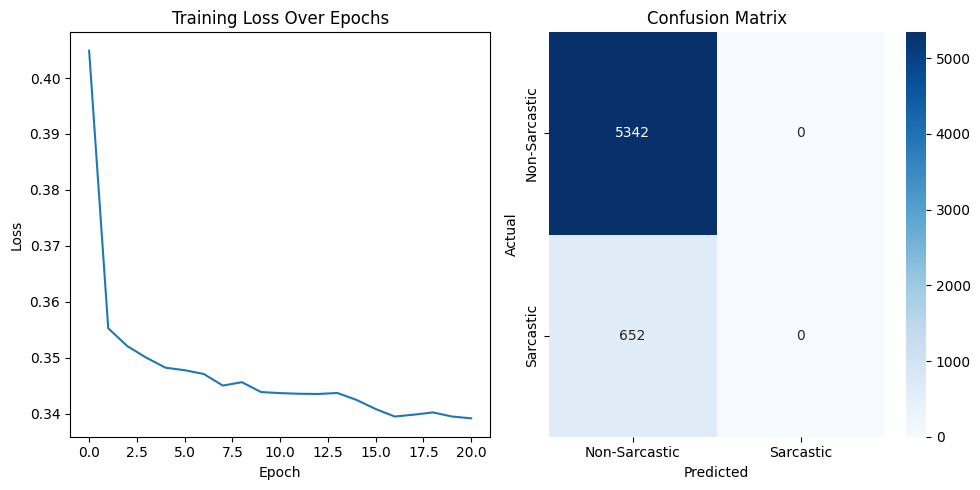

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
nltk.download('vader_lexicon')
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Ensure reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Load IAC and Onion datasets
print("Loading datasets...")
iac_data = pd.read_csv('IAC_dataset.csv')  # Replace with actual path
onion_data = pd.read_csv('Onion_data.csv')  # Replace with actual path

# Merge datasets
iac_data['label'] = 1  # Sarcasm
onion_data['label'] = 0  # Non-sarcasm
data = pd.concat([iac_data[['text', 'label']], onion_data[['text', 'label']]])

# Split into train/test sets
print("Splitting datasets...")
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42, stratify=data['label'])

# Initialize tools
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = SentimentIntensityAnalyzer()



# Emotional Incongruity Analysis
def extract_emotional_features(text):
    doc = nlp(text)
    emotions = [token.sentiment for token in doc if token.has_vector]
    if emotions:
        return np.var(emotions), max(emotions) - min(emotions)
    else:
        return 0, 0

# Pragmatic Expectation Violation
def pragmatic_violation_score(text):
    sentiment = sentiment_analyzer.polarity_scores(text)
    return sentiment['neg'] - sentiment['pos']

# Feature Engineering
def extract_features(texts):
    features = []
    for text in tqdm(texts, desc="Extracting Features", unit="text"):
        emotional_var, emotional_range = extract_emotional_features(text)
        pragmatic_score = pragmatic_violation_score(text)
        features.append([emotional_var, emotional_range, pragmatic_score])
    return np.array(features)

# Extract features for train and test sets
print("Extracting training features...")
train_features = extract_features(train_texts)
print("Extracting testing features...")
test_features = extract_features(test_texts)

class SarcasmDetectionModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SarcasmDetectionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)

# Convert data to tensors and move to GPU
train_tensor = torch.tensor(train_features, dtype=torch.float32).to(device)
train_labels_tensor = torch.tensor(train_labels.values, dtype=torch.float32).to(device)
test_tensor = torch.tensor(test_features, dtype=torch.float32).to(device)
test_labels_tensor = torch.tensor(test_labels.values, dtype=torch.float32).to(device)

# Initialize model and move to GPU
model = SarcasmDetectionModel(input_size=3, hidden_size=16).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 21
batch_size = 32
training_losses = []

print("Starting training...")
for epoch in tqdm(range(epochs), desc="Training Epochs", unit="epoch"):
    model.train()
    total_loss = 0
    for i in tqdm(range(0, len(train_tensor), batch_size), desc=f"Epoch {epoch+1} Batches", unit="batch", leave=False):
        batch_x = train_tensor[i:i + batch_size]
        batch_y = train_labels_tensor[i:i + batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / (len(train_tensor) // batch_size)
    training_losses.append(avg_loss)

# Evaluate on GPU
print("Evaluating model...")
model.eval()
with torch.no_grad():
    predictions = model(test_tensor).squeeze().cpu().numpy()
    binary_predictions = (predictions > 0.5).astype(int)

# Compute metrics with epsilon to prevent zero division
epsilon = 1e-7
accuracy = accuracy_score(test_labels_tensor.cpu(), binary_predictions)
f1 = f1_score(test_labels_tensor.cpu(), binary_predictions, zero_division=0)
precision = precision_score(test_labels_tensor.cpu(), binary_predictions, zero_division=0)
recall = recall_score(test_labels_tensor.cpu(), binary_predictions, zero_division=0)

# Print detailed performance metrics
print("\n--- Sarcasm Detection Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
#print(f"Precision: {precision:.4f} (Indicates the proportion of predicted sarcastic texts that are actually sarcastic)")
#print(f"Recall: {recall:.4f} (Indicates the proportion of actual sarcastic texts that were correctly identified)")
#print(f"F1 Score: {f1:.4f} (Harmonic mean of precision and recall, balancing both metrics)")

# Visualization 1: Training Loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(training_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Visualization 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(test_labels_tensor.cpu(), binary_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()